# 1.2. Exploratory Data Analysis
The purpose of this lab is to conduct exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

In [2]:
path = Path.cwd().parent / 'data' / 'processed' / 'api-launch-data-table-class.csv'
df = pd.read_csv(path)

In [3]:
df.head(5)

,launch_designator,booster_version,orbit,launch_site,flights,reused,landing_pad,block,serial,longitude,latitude,reused_count,outcome,OrbPay,launch_date,gridfins,legs,class
0,2020-084,Falcon 9,Low Earth Orbit,Launch Complex 39A,23,False,JRTI,Block 5,B1061,-80.604282,28.608227,0,True ASDS,13.0,2020-11-16,True,True,1
1,2020-078,Falcon 9,Medium Earth Orbit,Space Launch Complex 40,23,False,OCISLY,Block 5,B1062,-80.577357,28.561941,0,True ASDS,4.4,2020-11-05,True,True,1
2,2020-074,Falcon 9,Low Earth Orbit,Space Launch Complex 40,20,True,JRTI,Block 5,B1060,-80.577357,28.561941,2,True ASDS,16.0,2020-10-24,True,True,1
3,2020-073,Falcon 9,Low Earth Orbit,Launch Complex 39A,14,True,OCISLY,Block 5,B1051,-80.604282,28.608227,5,True ASDS,16.0,2020-10-18,True,True,1
4,2020-070,Falcon 9,Low Earth Orbit,Launch Complex 39A,19,True,OCISLY,Block 5,B1058,-80.604282,28.608227,2,True ASDS,16.0,2020-10-06,True,True,1


Plot the payload mass over time and label by launch outcome.

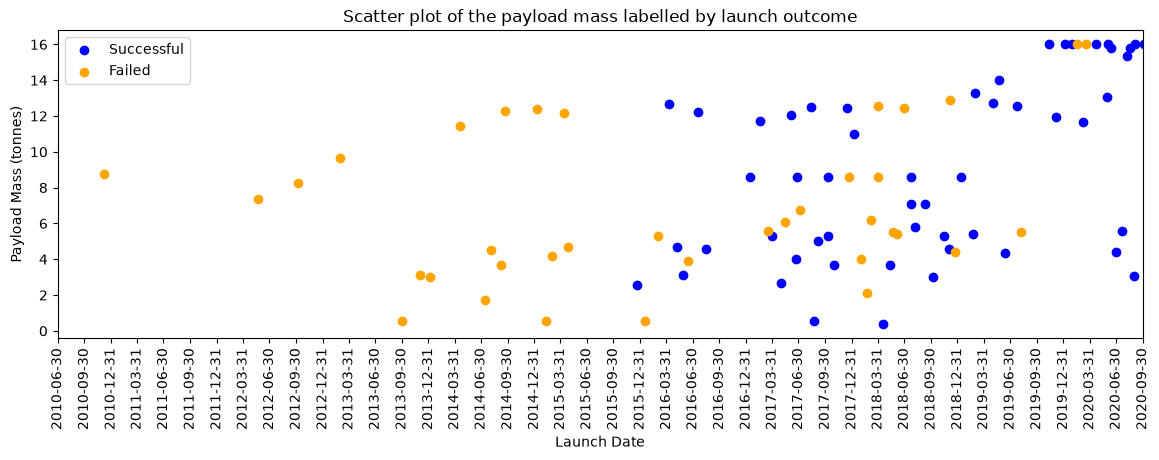

In [5]:
df1 = df[['OrbPay', 'class']]
df1.index = pd.to_datetime(df['launch_date'])

fig, ax = plt.subplots(figsize=(14,4))
mask = df1['class'] == 1
ax.scatter(df1[mask].index, df1[mask]['OrbPay'], color='blue', label='Successful')
ax.scatter(df1[~mask].index, df1[~mask]['OrbPay'], color='orange', label='Failed')

xticks = pd.date_range(start = df1.index.min(),
                      end = df1.index.max(),
                      freq = 'QE')
ax.set_xticks(xticks, xticks.strftime('%Y-%m-%d'), rotation=90)
ax.set_xlim(xticks.min(), xticks.max())
ax.set_xlabel('Launch Date')
ax.set_ylabel('Payload Mass (tonnes)')
ax.set_title('Scatter plot of the payload mass labelled by launch outcome')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'payload_time_series.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight:** From the plot of the payload and launch outcome over time, it can be seen that most of the latest flights were successful and were able to carry higher payloads.

Plot the launch site used over time and label with launch outcome.

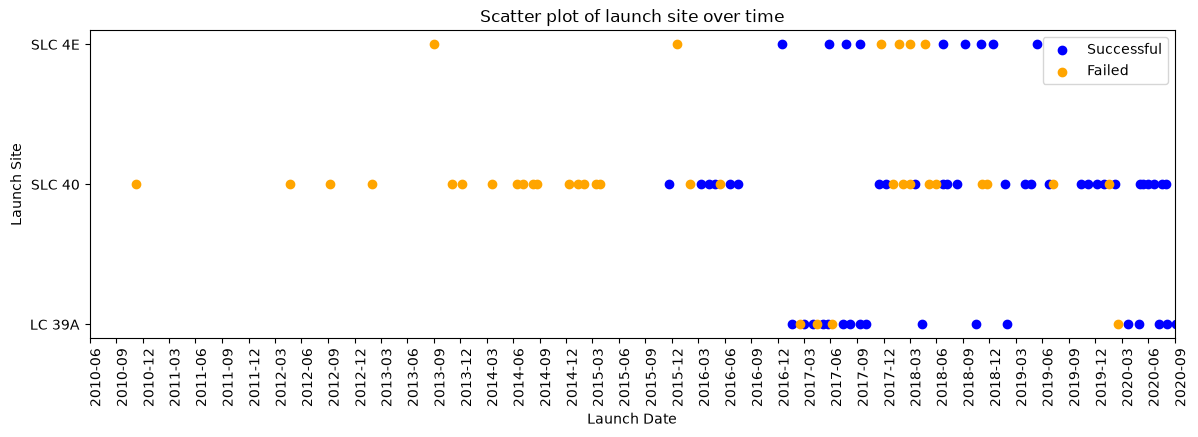

In [6]:
fig, ax = plt.subplots(figsize=(14,4))
mask = df['class'] == 1
xaxis = pd.to_datetime(df['launch_date'])

# Successful launches
ax.scatter(
    xaxis[mask],
    df[mask]['launch_site'],
    color = 'blue',
    label = 'Successful'
)

# Failed launches
ax.scatter(
    xaxis[~mask],
    df[~mask]['launch_site'],
    color= 'orange',
    label = 'Failed'
)

ax.set_xticks(xticks, xticks.strftime('%Y-%m'), rotation=90, ha='left')
ax.set_yticks(list(df['launch_site'].unique())[::-1], ['SLC 4E', 'SLC 40', 'LC 39A'])
ax.set_xlim(xticks.min(), xticks.max())
ax.set_xlabel('Launch Date')
ax.set_ylabel('Launch Site')
ax.set_title('Scatter plot of launch site over time')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'launchsite_time_series.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** SpaceX has done most of its launches in Space Launch Complex 40. At the beginning of their Falcon 9 projects, most of the launches in SLC 40 have failed to land but most of the recent launches in the site were successful. On the other hand, there were periods where all launches were conducted in either SLC 4E and LC 39A; particularly in late 2016 up to late 2017. Most of the launches by then were successful, but, overall, the LC 39A proved to be the best in terms of proportion of successful launches.

Visualize the relationship between payload and launch site

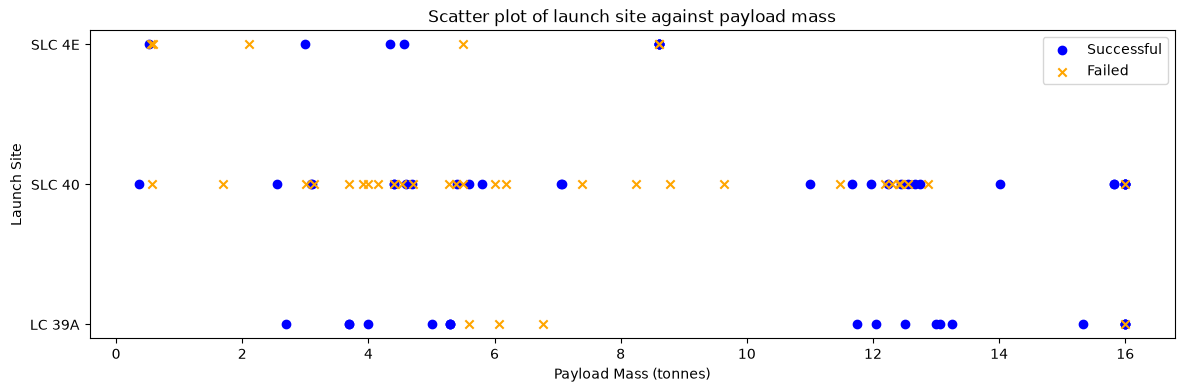

In [7]:
fig, ax = plt.subplots(figsize=(14,4))

# Successful launches
ax.scatter(
    df[mask]['OrbPay'],
    df[mask]['launch_site'],
    color = 'blue',
    label = 'Successful'
)

# Failed launches
ax.scatter(
    df[~mask]['OrbPay'],
    df[~mask]['launch_site'],
    color = 'orange',
    label = 'Failed',
    marker = 'x'
)

ax.set_yticks(list(df['launch_site'].unique())[::-1], ['SLC 4E', 'SLC 40', 'LC 39A'])
ax.set_xlabel('Payload Mass (tonnes)')
ax.set_ylabel('Launch Site')
ax.set_title('Scatter plot of launch site against payload mass')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'launchsite_vs_payload'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** At low payloads, launches in Space launch complex failed to land, but higher payloads resulted in successful missions. Furthermore, launches conducted in SLC 4E only reach up to 10 tonnes of payload. On the other hand, launches in LC 39A have landed successfully at a wide range of payloads with only 4 failed landings, 3 of which have similar payloads.

Visualize the relationship between orbit type and success rate

In [8]:
success_count = df.groupby('orbit')['class'].sum()
total_missions = df.groupby('orbit')['class'].count()
success_count

orbit
Geostationary Transfer Orbit    13
Heliocentric L1                  0
High Earth Orbit                 1
Low Earth Orbit                 34
Lunar Orbit                      1
Medium Earth Orbit               2
Polar Orbit                      1
Sun-Synchronous Orbit            5
Name: class, dtype: int64

In [9]:
total_missions

orbit
Geostationary Transfer Orbit    28
Heliocentric L1                  1
High Earth Orbit                 1
Low Earth Orbit                 54
Lunar Orbit                      1
Medium Earth Orbit               3
Polar Orbit                      1
Sun-Synchronous Orbit            6
Name: class, dtype: int64

In [10]:
success_rate = 100*success_count/total_missions #in percent (%)
success_rate = success_rate.sort_values(ascending=True)
success_rate

orbit
Heliocentric L1                   0.000000
Geostationary Transfer Orbit     46.428571
Low Earth Orbit                  62.962963
Medium Earth Orbit               66.666667
Sun-Synchronous Orbit            83.333333
High Earth Orbit                100.000000
Lunar Orbit                     100.000000
Polar Orbit                     100.000000
Name: class, dtype: float64

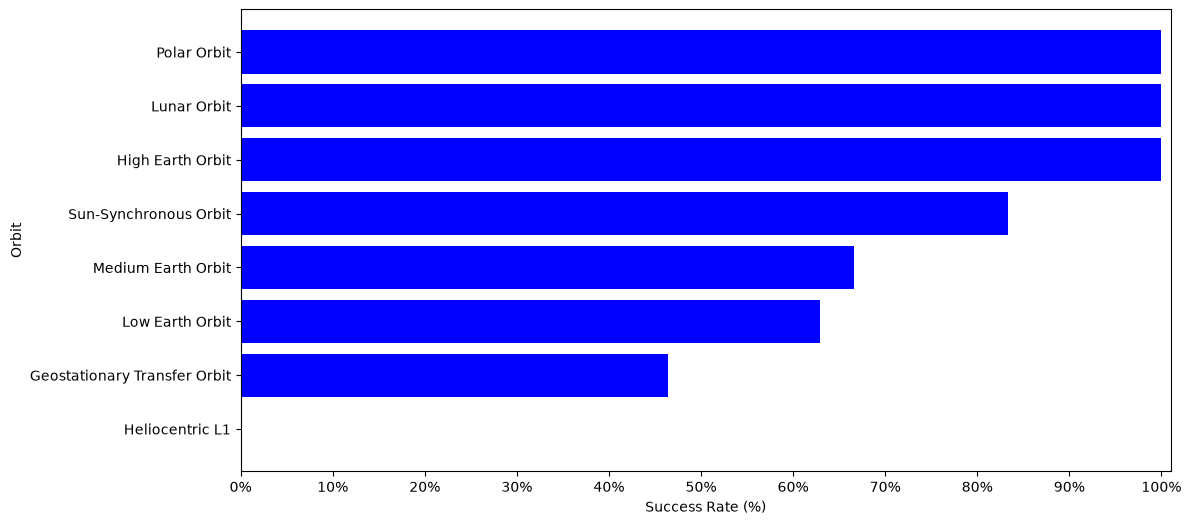

In [11]:
fig = plt.figure(figsize=(12,6))
plt.barh(success_rate.index, success_rate.values, color='blue')
plt.xlabel('Success Rate (%)')
plt.xlim(success_rate.values.min(), success_rate.values.max()+1)
plt.xticks(np.arange(0,110,10), list(map(lambda x: '{:.0f}%'.format(x), np.arange(0,110,10))))
plt.ylabel('Orbit')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'success_rate_orbits.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.show()

Visualize the trend of orbit type over time colored by class.

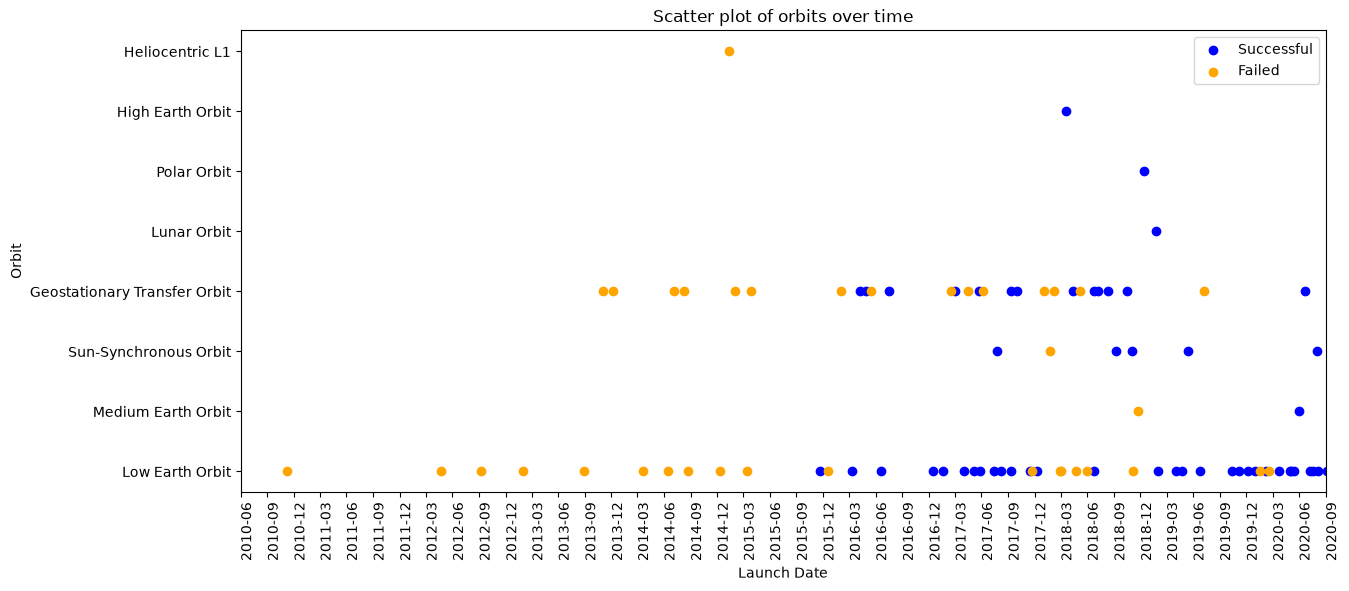

In [12]:
fig, ax = plt.subplots(figsize=(14,6))
df2 = df.dropna(axis=0)
mask = df2['class'] == 1
xaxis = pd.to_datetime(df2['launch_date'])

# Successful launches
ax.scatter(
    xaxis[mask],
    df2[mask]['orbit'],
    color = 'blue',
    label = 'Successful'
)

# Failed launches
ax.scatter(
    xaxis[~mask],
    df2[~mask]['orbit'],
    color= 'orange',
    label = 'Failed'
)

ax.set_xticks(xticks, xticks.strftime('%Y-%m'), rotation=90, ha='left')
ax.set_yticks(list(df2['orbit'].unique())[::-1])
ax.set_xlim(xticks.min(), xticks.max())
ax.set_xlabel('Launch Date')
ax.set_ylabel('Orbit')
ax.set_title('Scatter plot of orbits over time')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'orbits_time_series.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** Most successful missions are clustered at later dates for any orbit. There was one mission around the Heliocentric L1 orbit, and that one mission failed; but it was conducted at an earlier date and was not attempted later. Many of the launches were missions around the Low Earth Orbit and were mostly successful at later dates. Furthermore, it appears that, for missions around the Geostationary Transfer Orbit, launch date and mission outcome have the weakest relationship.

Visualize the relationship between payload and orbit type.

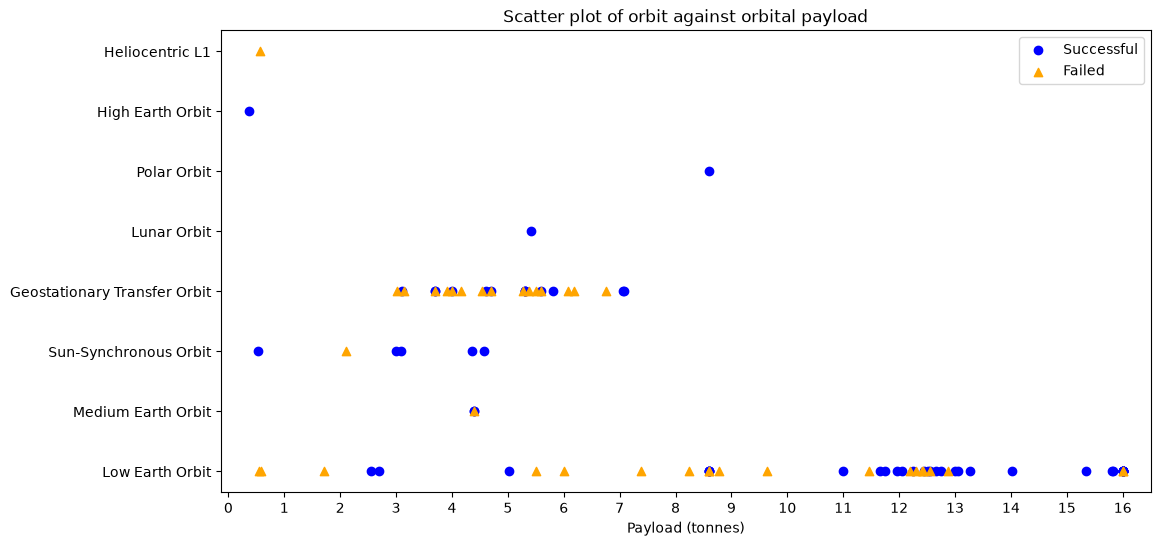

In [13]:
fig,ax = plt.subplots(figsize=(12,6))
ax.scatter(df2[mask]['OrbPay'], df2[mask]['orbit'] , color='blue', marker='o', label='Successful')
ax.scatter(df2[~mask]['OrbPay'], df2[~mask]['orbit'], color='orange', marker='^', label='Failed')
ax.set_xlim(df2['OrbPay'].min()-0.5, df2['OrbPay'].max()+0.5)
ax.set_xticks(np.arange(0,17))
ax.set_xlabel('Payload (tonnes)')
ax.set_title('Scatter plot of orbit against orbital payload')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'orbit_vs_payload.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** For missions around the Low Earth Orbit and the Sun-Synchronous Orbit, a higher payload roughly results in a successful flight. Similar to orbit against launch dates, there is no clear relationship between outcome and payload mass for missions around the geostationary orbit. It is even more difficult to assess the relationship for the rest of the orbits.

In [15]:
df3 = df.set_index(pd.to_datetime(df['launch_date']))
success_count_year = df3.resample('YE')['class'].mean().dropna(axis=0)

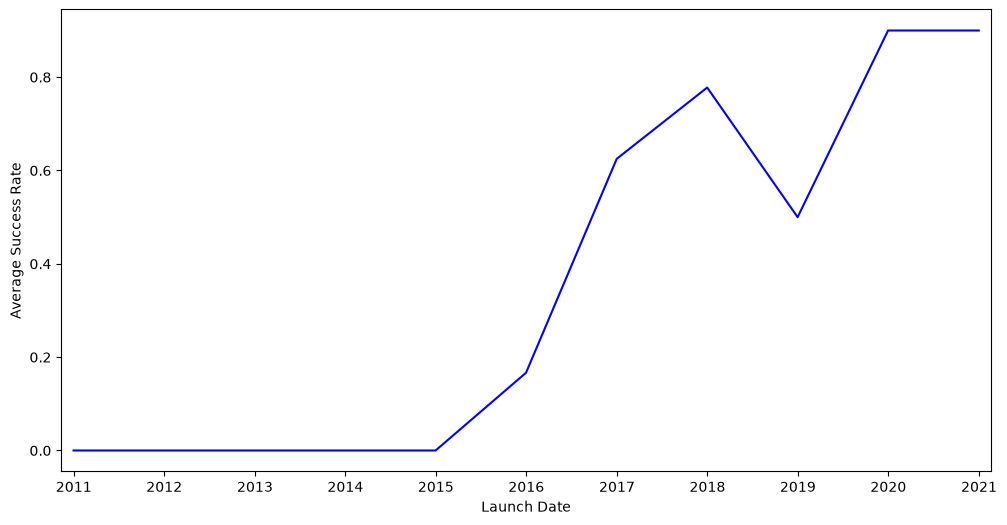

In [17]:
from datetime import timedelta

fig = plt.figure(figsize=(12,6))
plt.plot(success_count_year.index, success_count_year.values, color = 'blue')
plt.xlim(success_count_year.index.min() - timedelta(days=50),success_count_year.index.max() + timedelta(days=50))
plt.xlabel('Launch Date')
plt.ylabel('Average Success Rate')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'mean_success_rate.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.show()